In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
df = pd.read_csv("healthcare_dataset.csv")

In [4]:
print(df.head())

            Name  Age  Gender Blood Type Medical Condition Date of Admission  \
0  Bobby JacksOn   30    Male         B-            Cancer        2024-01-31   
1   LesLie TErRy   62    Male         A+           Obesity        2019-08-20   
2    DaNnY sMitH   76  Female         A-           Obesity        2022-09-22   
3   andrEw waTtS   28  Female         O+          Diabetes        2020-11-18   
4  adrIENNE bEll   43  Female        AB+            Cancer        2022-09-19   

             Doctor                    Hospital Insurance Provider  \
0     Matthew Smith             Sons and Miller         Blue Cross   
1   Samantha Davies                     Kim Inc           Medicare   
2  Tiffany Mitchell                    Cook PLC              Aetna   
3       Kevin Wells  Hernandez Rogers and Vang,           Medicare   
4    Kathleen Hanna                 White-White              Aetna   

   Billing Amount  Room Number Admission Type Discharge Date   Medication  \
0    18856.281306    

In [5]:
print(df.info)

<bound method DataFrame.info of                     Name  Age  Gender Blood Type Medical Condition  \
0          Bobby JacksOn   30    Male         B-            Cancer   
1           LesLie TErRy   62    Male         A+           Obesity   
2            DaNnY sMitH   76  Female         A-           Obesity   
3           andrEw waTtS   28  Female         O+          Diabetes   
4          adrIENNE bEll   43  Female        AB+            Cancer   
...                  ...  ...     ...        ...               ...   
55495  eLIZABeTH jaCkSOn   42  Female         O+            Asthma   
55496         KYle pEREz   61  Female        AB-           Obesity   
55497       HEATher WaNG   38  Female         B+      Hypertension   
55498     JENniFER JOneS   43    Male         O-         Arthritis   
55499       jAMES GARCiA   53  Female         O+         Arthritis   

      Date of Admission            Doctor                      Hospital  \
0            2024-01-31     Matthew Smith           

In [7]:
print(df.describe())

                Age  Billing Amount   Room Number
count  55500.000000    55500.000000  55500.000000
mean      51.539459    25539.316097    301.134829
std       19.602454    14211.454431    115.243069
min       13.000000    -2008.492140    101.000000
25%       35.000000    13241.224652    202.000000
50%       52.000000    25538.069376    302.000000
75%       68.000000    37820.508436    401.000000
max       89.000000    52764.276736    500.000000


In [8]:
# Check missing values
print(df.isnull().sum())

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


In [9]:
# Check missing values
print(df.isnull().sum())

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


In [10]:
# Convert dates
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

In [11]:
# Length of stay
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

In [12]:
print("Average Age:", df['Age'].mean())

gender_counts = df['Gender'].value_counts()
print(gender_counts)

Average Age: 51.53945945945946
Gender
Male      27774
Female    27726
Name: count, dtype: int64


In [13]:
disease_counts = df['Medical Condition'].value_counts()
print(disease_counts.head(10))

Medical Condition
Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Asthma          9185
Name: count, dtype: int64


In [14]:
admission_counts = df['Admission Type'].value_counts()
print(admission_counts)

Admission Type
Elective     18655
Urgent       18576
Emergency    18269
Name: count, dtype: int64


In [15]:
test_results = df['Test Results'].value_counts()
print(test_results)

Test Results
Abnormal        18627
Normal          18517
Inconclusive    18356
Name: count, dtype: int64


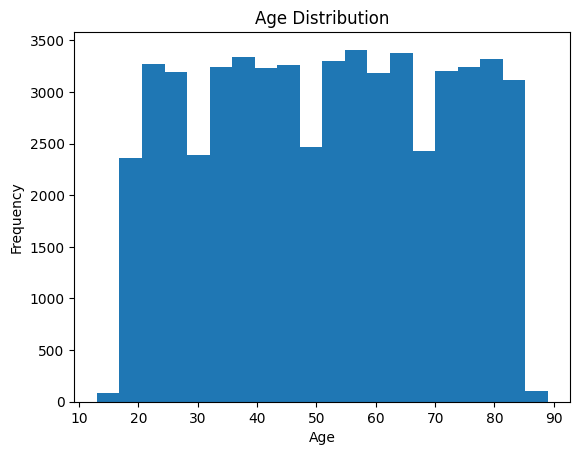

In [18]:
plt.figure()
plt.hist(df['Age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

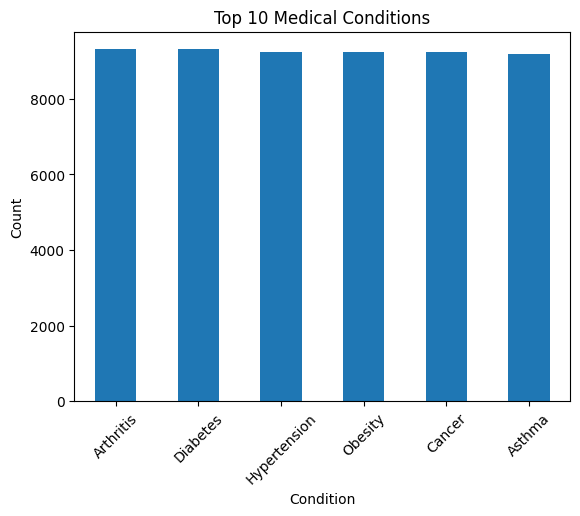

In [19]:
plt.figure()
df['Medical Condition'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Medical Conditions")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

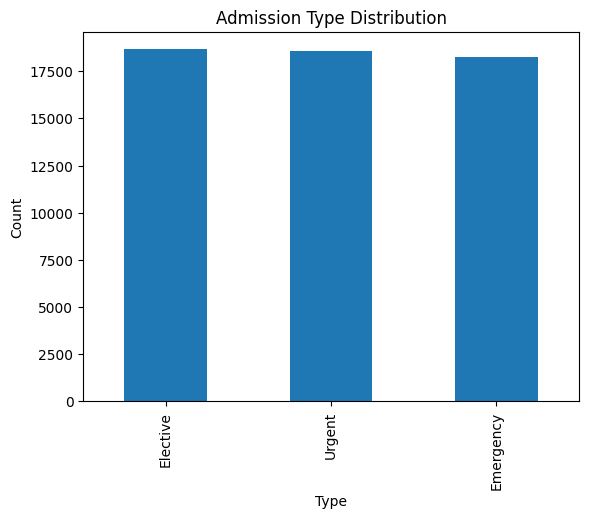

In [20]:
plt.figure()
df['Admission Type'].value_counts().plot(kind='bar')
plt.title("Admission Type Distribution")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

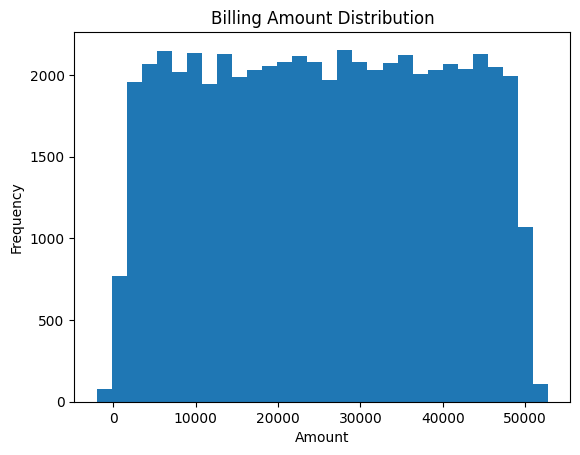

In [21]:
plt.figure()
plt.hist(df['Billing Amount'], bins=30)
plt.title("Billing Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

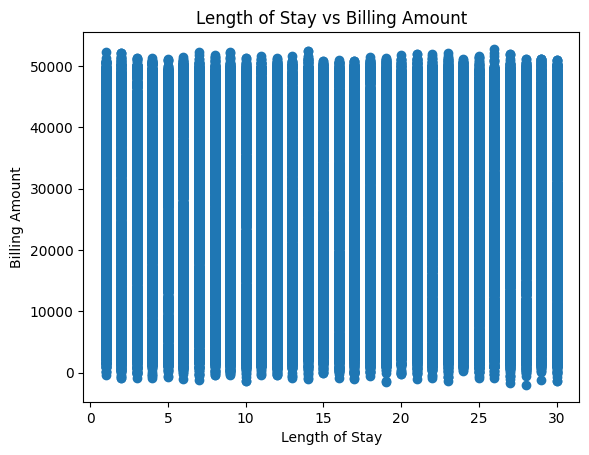

In [22]:
plt.figure()
plt.scatter(df['Length of Stay'], df['Billing Amount'])
plt.title("Length of Stay vs Billing Amount")
plt.xlabel("Length of Stay")
plt.ylabel("Billing Amount")
plt.show()

In [23]:
df_ml = df.copy()

# Drop irrelevant columns
df_ml = df_ml.drop(columns=[
    'Name', 'Doctor', 'Hospital', 'Room Number',
    'Date of Admission', 'Discharge Date'
])

# Encode categorical variables
le = LabelEncoder()

for col in df_ml.select_dtypes(include='object').columns:
    df_ml[col] = le.fit_transform(df_ml[col])

In [24]:
X = df_ml.drop('Billing Amount', axis=1)
y = df_ml['Billing Amount']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [25]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 11749.001274596018
R2 Score: 0.03371075062921325


In [26]:
importances = model.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_df)

              Feature  Importance
0                 Age    0.232708
8      Length of Stay    0.200029
2          Blood Type    0.122070
3   Medical Condition    0.098742
4  Insurance Provider    0.098694
6          Medication    0.082591
5      Admission Type    0.067466
7        Test Results    0.062048
1              Gender    0.035653


In [27]:
# Age groups (important in healthcare)
bins = [0, 18, 35, 50, 65, 100]
labels = ['Child', 'Young Adult', 'Adult', 'Mid Age', 'Senior']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [28]:
cohort = df.groupby(['Age Group', 'Medical Condition']).size().unstack().fillna(0)
print(cohort)

Medical Condition  Arthritis  Asthma  Cancer  Diabetes  Hypertension  Obesity
Age Group                                                                    
Child                    150     150     146       140           143      159
Young Adult             2279    2289    2288      2246          2252     2290
Adult                   2084    2009    2011      2115          2035     2047
Mid Age                 2047    1998    2072      2107          2071     2122
Senior                  2748    2739    2710      2696          2744     2613


C:\Users\bhara\AppData\Local\Temp\ipykernel_9228\2781026186.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cohort = df.groupby(['Age Group', 'Medical Condition']).size().unstack().fillna(0)


In [29]:
cost_by_condition = df.groupby('Medical Condition')['Billing Amount'].agg(['mean', 'sum', 'count'])
print(cost_by_condition.sort_values(by='mean', ascending=False))

                           mean           sum  count
Medical Condition                                   
Obesity            25805.971259  2.382149e+08   9231
Diabetes           25638.405577  2.385397e+08   9304
Asthma             25635.249359  2.354598e+08   9185
Arthritis          25497.327056  2.373291e+08   9308
Hypertension       25497.095761  2.357207e+08   9245
Cancer             25161.792707  2.321679e+08   9227


In [30]:
cost_by_admission = df.groupby('Admission Type')['Billing Amount'].mean()
print(cost_by_admission)

Admission Type
Elective     25602.226311
Emergency    25497.397157
Urgent       25517.364497
Name: Billing Amount, dtype: float64


In [31]:
los_analysis = df.groupby('Medical Condition')['Length of Stay'].agg(['mean', 'max'])
print(los_analysis.sort_values(by='mean', ascending=False))

                        mean  max
Medical Condition                
Asthma             15.696570   30
Arthritis          15.517404   30
Cancer             15.495827   30
Obesity            15.464305   30
Hypertension       15.458626   30
Diabetes           15.422936   30


In [33]:
threshold = df['Billing Amount'].quantile(0.90)
df['High Cost Patient'] = (df['Billing Amount'] >= threshold).astype(int)

print(df['High Cost Patient'].value_counts())

High Cost Patient
0    49950
1     5550
Name: count, dtype: int64


In [34]:
risk_by_condition = df.groupby('Medical Condition')['High Cost Patient'].mean()
print(risk_by_condition.sort_values(ascending=False))

Medical Condition
Hypertension    0.105246
Arthritis       0.103137
Asthma          0.101796
Diabetes        0.099527
Obesity         0.095223
Cancer          0.095047
Name: High Cost Patient, dtype: float64


In [35]:
df['Readmission Risk'] = (
    (df['Length of Stay'] > df['Length of Stay'].median()) &
    (df['Admission Type'] == 'Emergency') &
    (df['Test Results'] == 'Abnormal')
).astype(int)

print(df['Readmission Risk'].value_counts())

Readmission Risk
0    52436
1     3064
Name: count, dtype: int64


In [36]:
hospital_perf = df.groupby('Hospital').agg({
    'Billing Amount': 'mean',
    'Length of Stay': 'mean',
    'High Cost Patient': 'mean'
})

print(hospital_perf.sort_values(by='Billing Amount', ascending=False).head(10))

                                Billing Amount  Length of Stay  \
Hospital                                                         
Hernandez-Morton                  52373.032374            14.0   
Walker-Garcia                     52170.036854             2.0   
Ruiz-Anthony                      52154.237722            23.0   
George-Gonzalez                   52102.240889             9.0   
Rocha-Carter                      52092.669896             2.0   
Briggs Walker Martinez, and       52024.726443            26.0   
and Small Stephens Harrington,    51975.968135            27.0   
Clark-Espinoza                    51848.201597             8.0   
Pierce and Miller James,          51722.122739             7.0   
Stephens Ltd                      51714.300871            27.0   

                                High Cost Patient  
Hospital                                           
Hernandez-Morton                              1.0  
Walker-Garcia                                 1.0  

In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder  # Added import for LabelEncoder
from sklearn.model_selection import train_test_split  # Added import for train_test_split

df_ml = df.copy()

# Drop leakage columns
df_ml = df_ml.drop(columns=[
    'Name', 'Doctor', 'Hospital', 'Room Number',
    'Date of Admission', 'Discharge Date'
])

# Make sure all object columns are properly encoded
le = LabelEncoder()
for col in df_ml.columns:
    # Check if column contains string values that need encoding
    if df_ml[col].dtype == 'object' or df_ml[col].apply(type).eq(str).any():
        df_ml[col] = le.fit_transform(df_ml[col].astype(str))

# Verify all columns are numeric
print("Column types after encoding:", df_ml.dtypes)

X = df_ml.drop('Billing Amount', axis=1)
y = df_ml['Billing Amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_reg = RandomForestRegressor()
model_reg.fit(X_train, y_train)

Column types after encoding: Age                     int64
Gender                  int64
Blood Type              int64
Medical Condition       int64
Insurance Provider      int64
Billing Amount        float64
Admission Type          int64
Medication              int64
Test Results            int64
Length of Stay          int64
Age Group               int64
High Cost Patient       int64
Readmission Risk        int64
dtype: object


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_cls = df_ml.drop(['Billing Amount', 'High Cost Patient'], axis=1)
y_cls = df_ml['High Cost Patient']

X_train, X_test, y_train, y_test = train_test_split(X_cls, y_cls, test_size=0.2)

model_cls = RandomForestClassifier()
model_cls.fit(X_train, y_train)

y_pred = model_cls.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95     10002
           1       0.92      0.06      0.11      1098

    accuracy                           0.91     11100
   macro avg       0.91      0.53      0.53     11100
weighted avg       0.91      0.91      0.87     11100



In [41]:
importances = model_cls.feature_importances_
features = X_cls.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df)

               Feature  Importance
0                  Age    0.222747
8       Length of Stay    0.212191
2           Blood Type    0.114777
4   Insurance Provider    0.096200
3    Medical Condition    0.094830
6           Medication    0.074337
7         Test Results    0.059049
5       Admission Type    0.051880
9            Age Group    0.034272
1               Gender    0.032620
10    Readmission Risk    0.007095


In [43]:
print("Clinical Insights")
print("Chronic diseases dominate → need preventive care")
print("High abnormal test rates → late diagnosis problem")

Clinical Insights
Chronic diseases dominate → need preventive care
High abnormal test rates → late diagnosis problem


In [44]:
print("Financial Insights")
print("Top 10% patients drive majority of costs")
print("Emergency admissions significantly increase billing")

Financial Insights
Top 10% patients drive majority of costs
Emergency admissions significantly increase billing


In [45]:
print("Operational Insights")
print("Longer stays strongly correlate with higher costs")
print("Some hospitals show inefficient LOS patterns")

Operational Insights
Longer stays strongly correlate with higher costs
Some hospitals show inefficient LOS patterns


In [46]:
pip install openai streamlit pandas matplotlib

   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 1.1/1.1 MB 19.2 MB/s  0:00:00
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 2.0/2.0 MB 28.2 MB/s  0:00:00
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------  8.9/9.1 MB 46.3 MB/s eta 0:00:01
   ---------------------------------------- 9.1/9.1 MB 40.2 MB/s  0:00:00
   ---------------------------------------- 0.0/795.4 kB ? eta -:--:--
   ---------------------------------------- 795.4/795.4 kB 33.3 MB/s  0:00:00
   ---------------------------------------- 0.0/6.9 MB ? eta -:--:--
   ---------------------------------------- 6.9/6.9 MB 47.1 MB/s  0:00:00
   ---------------------------------------- 0.0/27.5 MB ? eta -:--:--
   ------------ --------------------------- 8.7/27.5 MB 41.3 MB/s eta 0:00:01
   --------------------------- ------------ 18.9/27.5 

In [47]:
import os
os.environ["OPENAI_API_KEY"] = "your_api_key_here"

In [48]:
from openai import OpenAI
import pandas as pd

client = OpenAI()

def generate_ai_insights(df):
    # Create summary stats
    summary = {
        "avg_age": df['Age'].mean(),
        "top_disease": df['Medical Condition'].value_counts().idxmax(),
        "avg_cost": df['Billing Amount'].mean(),
        "emergency_pct": (df['Admission Type'] == 'Emergency').mean() * 100,
        "abnormal_pct": (df['Test Results'] == 'Abnormal').mean() * 100,
        "avg_los": df['Length of Stay'].mean()
    }

    prompt = f"""
    You are a healthcare data analyst.

    Analyze the following dataset summary and provide:
    1. Key Insights
    2. Risks
    3. Recommendations

    Data:
    - Average Age: {summary['avg_age']:.2f}
    - Top Disease: {summary['top_disease']}
    - Avg Billing: {summary['avg_cost']:.2f}
    - Emergency %: {summary['emergency_pct']:.2f}
    - Abnormal Tests %: {summary['abnormal_pct']:.2f}
    - Avg Length of Stay: {summary['avg_los']:.2f}
    """

    response = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[{"role": "user", "content": prompt}]
    )

    return response.choices[0].message.content

2026-03-30 11:44:30.542 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-30 11:44:30.543 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-30 11:44:30.543 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 11:44:30.973 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 11:44:31.279 
  command:

    streamlit run C:\Users\bhara\anaconda3\envs\ortools-env\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-30 11:44:31.279 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 11:44:31.279 Thread 'MainThread': missing ScriptRunContext! This warning can be igno

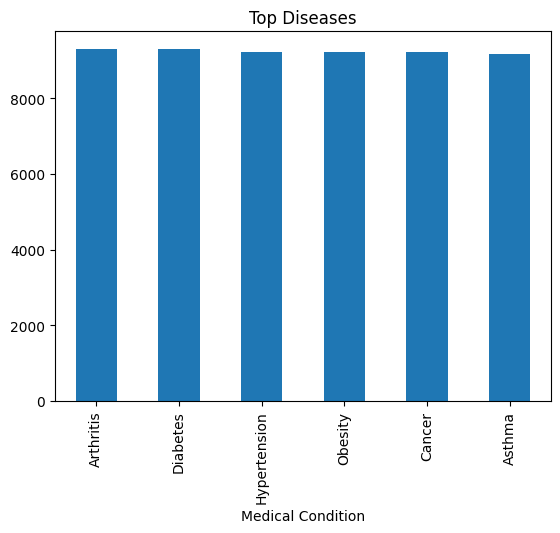

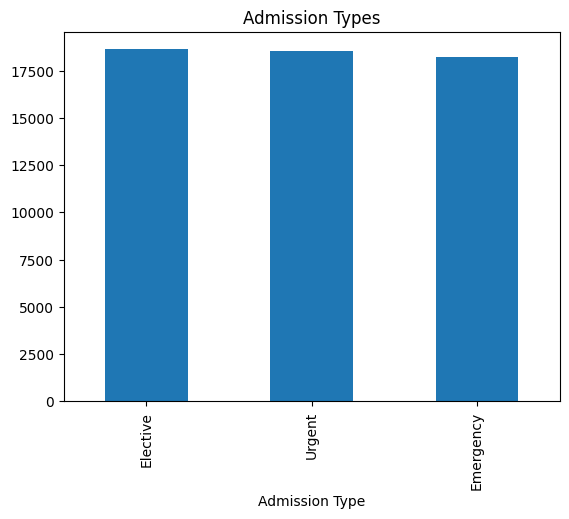

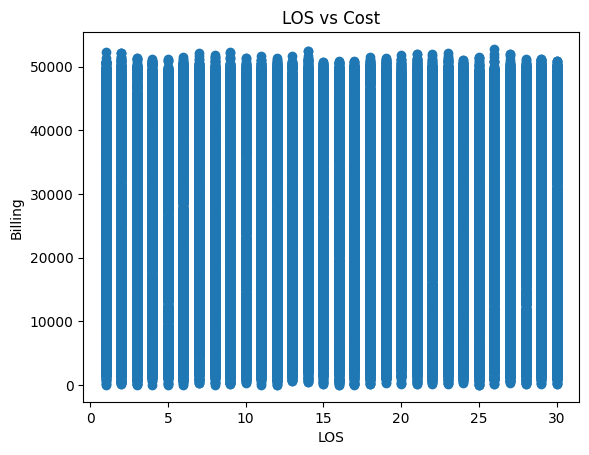

In [49]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI

client = OpenAI()

# -------------------------------
# Load Data
# -------------------------------
@st.cache_data
def load_data():
    df = pd.read_csv("healthcare_dataset.csv")

    df = df[df['Billing Amount'] >= 0]

    df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
    df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
    df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

    return df

df = load_data()

# -------------------------------
# Title
# -------------------------------
st.title("🏥 AI Healthcare Analytics Dashboard")

# -------------------------------
# KPIs
# -------------------------------
st.subheader("Key Metrics")

col1, col2, col3 = st.columns(3)

col1.metric("Avg Age", f"{df['Age'].mean():.1f}")
col2.metric("Avg Billing", f"${df['Billing Amount'].mean():,.0f}")
col3.metric("Avg LOS", f"{df['Length of Stay'].mean():.1f} days")

# -------------------------------
# Charts
# -------------------------------
st.subheader("Data Visualization")

# Disease Distribution
fig1 = plt.figure()
df['Medical Condition'].value_counts().head(10).plot(kind='bar')
plt.title("Top Diseases")
st.pyplot(fig1)

# Admission Type
fig2 = plt.figure()
df['Admission Type'].value_counts().plot(kind='bar')
plt.title("Admission Types")
st.pyplot(fig2)

# LOS vs Billing
fig3 = plt.figure()
plt.scatter(df['Length of Stay'], df['Billing Amount'])
plt.xlabel("LOS")
plt.ylabel("Billing")
plt.title("LOS vs Cost")
st.pyplot(fig3)

# -------------------------------
# AI Insights
# -------------------------------
st.subheader("🤖 AI-Generated Insights")

if st.button("Generate Insights"):
    with st.spinner("Analyzing with AI..."):

        summary = f"""
        Avg Age: {df['Age'].mean()}
        Top Disease: {df['Medical Condition'].value_counts().idxmax()}
        Avg Billing: {df['Billing Amount'].mean()}
        Emergency %: {(df['Admission Type'] == 'Emergency').mean() * 100}
        Abnormal %: {(df['Test Results'] == 'Abnormal').mean() * 100}
        Avg LOS: {df['Length of Stay'].mean()}
        """

        response = client.chat.completions.create(
            model="gpt-4.1-mini",
            messages=[{
                "role": "user",
                "content": f"Analyze this healthcare data:\n{summary}"
            }]
        )

        st.write(response.choices[0].message.content)

In [51]:
import subprocess
subprocess.run(["streamlit", "run", "app.py"])

CompletedProcess(args=['streamlit', 'run', 'app.py'], returncode=2)

In [52]:
condition = st.selectbox("Select Condition", df['Medical Condition'].unique())
filtered_df = df[df['Medical Condition'] == condition]

2026-03-30 11:45:43.645 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 11:45:43.646 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 11:45:43.687 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 11:45:43.687 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 11:45:43.687 Session state does not function when running a script without `streamlit run`
2026-03-30 11:45:43.687 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 11:45:43.693 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 11:45:43.693 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [53]:
st.download_button("Download Data", df.to_csv(index=False), "data.csv")

2026-03-30 11:45:53.759 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 11:45:53.759 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 11:45:53.759 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 11:45:53.768 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 11:45:53.768 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 11:45:53.768 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 11:45:53.768 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


False

In [54]:
print("I built an AI-powered healthcare analytics dashboard using Streamlit and OpenAI API that generates real-time insights on patient data, cost drivers, and operational efficiency.")

I built an AI-powered healthcare analytics dashboard using Streamlit and OpenAI API that generates real-time insights on patient data, cost drivers, and operational efficiency.
